In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

file_path = "dmi_7924_noaa.txt"
data = pd.read_csv(file_path, delim_whitespace=True, header=None)
data = pd.read_csv(file_path, sep=r"\s+", header=None)

C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_23944\3175386469.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)


In [2]:
print("Shape:", data.shape)
print(data.head())


Shape: (46, 12)
      0      1      2      3      4      5      6      7      8      9   \
0  0.317 -0.158 -0.034 -0.207 -0.444  0.108 -0.315 -0.226 -0.280 -0.314   
1 -0.158 -0.200 -0.417 -0.095 -0.066 -0.382 -0.661 -0.822 -0.745 -0.657   
2 -0.201 -0.024  0.027  0.092 -0.018 -0.240 -0.560 -0.628 -0.757 -0.606   
3  0.144  0.166  0.054  0.119  0.223  0.255  0.265  0.256  0.442  0.623   
4 -0.482 -0.587 -0.752 -0.556 -0.059  0.371  0.525  0.345 -0.069 -0.288   

      10     11  
0 -0.251 -0.101  
1 -0.417 -0.483  
2 -0.328 -0.019  
3  0.284 -0.162  
4 -0.343 -0.101  


In [3]:
X = data.iloc[:, :-1]   # first 11 columns
y = data.iloc[:, -1]    # last column

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
# 6. Predictions
y_pred = model.predict(X_test)

# 7. Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# 8. Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# 9. Regression Equation
eq = "Y = " + str(model.intercept_)
for i, coef in enumerate(model.coef_):
    eq += f" + ({coef})*X{i+1}"

print("Regression Equation:")
print(eq)

R2 Score: 0.5075633625574775
RMSE: 0.2147312423611244
Intercept: -0.015654574874380767
Coefficients: [-0.06762557  0.1589687  -0.05745298 -0.24688134 -0.2356018   0.36572389
 -0.07734467  0.52862011 -0.34639329 -0.18205661  0.60910907]
Regression Equation:
Y = -0.015654574874380767 + (-0.06762557304561667)*X1 + (0.15896870442489575)*X2 + (-0.05745297886501887)*X3 + (-0.24688134064380501)*X4 + (-0.23560179999023045)*X5 + (0.3657238887440161)*X6 + (-0.07734466566474849)*X7 + (0.5286201103479898)*X8 + (-0.34639328766698996)*X9 + (-0.18205660841759408)*X10 + (0.609109073631652)*X11


C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_23944\28107696.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)
C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_23944\28107696.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dmi = pd.read_csv(dmi_file, delim_whitespace=True, header=None)



===== MODEL RESULTS =====
Intercept: 286.7922987976055
Coefficient (ENSO): 0.036633805799491104
Coefficient (DMI): -0.038897859865497916
R² Score: 0.07095737312457595


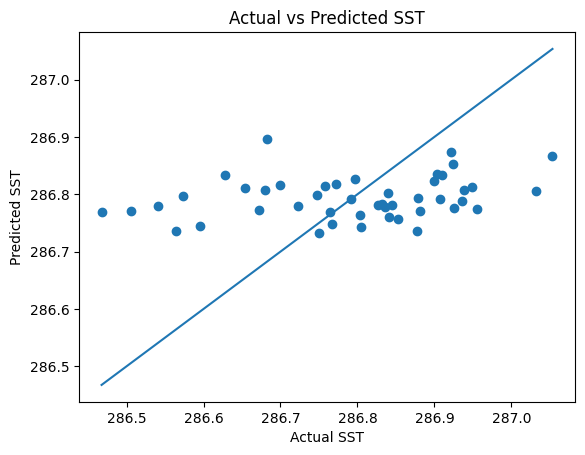

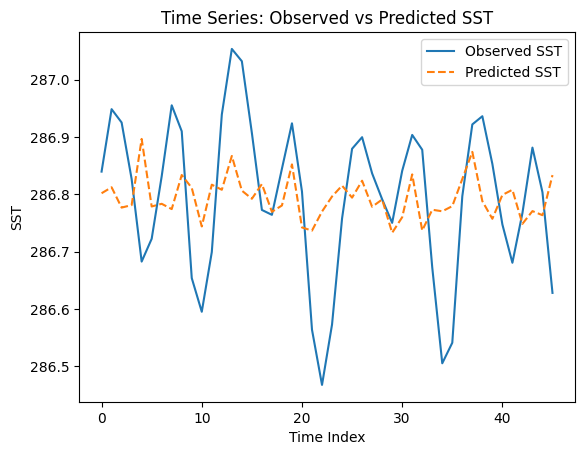

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Load ENSO (Nino 3.4)
# -----------------------------
enso_file = "nino-3.4_7924_noaa.txt"
enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)
enso_index = enso.iloc[:, 1].values

# -----------------------------
# Load DMI (IOD)
# -----------------------------
dmi_file = "dmi_7924_noaa.txt"
dmi = pd.read_csv(dmi_file, delim_whitespace=True, header=None)
dmi_index = dmi.iloc[:, 1].values

# -----------------------------
# Load SST NetCDF file
# -----------------------------
sst_file = "ERA5_SST_sst_K_monmean_7924_1.nc"
ds = xr.open_dataset(sst_file)

sst = ds['sst']

# Global mean SST
sst_mean = sst.mean(dim=["lat", "lon"])
sst_values = sst_mean.values

# -----------------------------
# Match lengths
# -----------------------------
min_len = min(len(enso_index), len(dmi_index), len(sst_values))

enso_index = enso_index[:min_len]
dmi_index = dmi_index[:min_len]
sst_values = sst_values[:min_len]

# -----------------------------
# Remove NaN values (important)
# -----------------------------
mask = ~np.isnan(enso_index) & ~np.isnan(dmi_index) & ~np.isnan(sst_values)

enso_index = enso_index[mask]
dmi_index = dmi_index[mask]
sst_values = sst_values[mask]

# -----------------------------
# Prepare X and y
# -----------------------------
X = np.column_stack((enso_index, dmi_index))  # 2 inputs
y = sst_values

# -----------------------------
# Train Model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# -----------------------------
# Results
# -----------------------------
print("\n===== MODEL RESULTS =====")
print("Intercept:", model.intercept_)
print("Coefficient (ENSO):", model.coef_[0])
print("Coefficient (DMI):", model.coef_[1])
print("R² Score:", model.score(X, y))

# -----------------------------
# Plot 1: Actual vs Predicted
# -----------------------------
plt.figure()
plt.scatter(y, y_pred)
plt.xlabel("Actual SST")
plt.ylabel("Predicted SST")
plt.title("Actual vs Predicted SST")

# Perfect fit line
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.show()

# -----------------------------
# Plot 2: Time Series Comparison
# -----------------------------
plt.figure()
plt.plot(y, label="Observed SST")
plt.plot(y_pred, linestyle="--", label="Predicted SST")

plt.xlabel("Time Index")
plt.ylabel("SST")
plt.title("Time Series: Observed vs Predicted SST")
plt.legend()
plt.show()



C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_23944\1815358217.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  enso_df = pd.read_csv(enso_file, delim_whitespace=True, header=None)
C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_23944\1815358217.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dmi_df  = pd.read_csv(dmi_file,  delim_whitespace=True, header=None)
C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_23944\1815358217.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


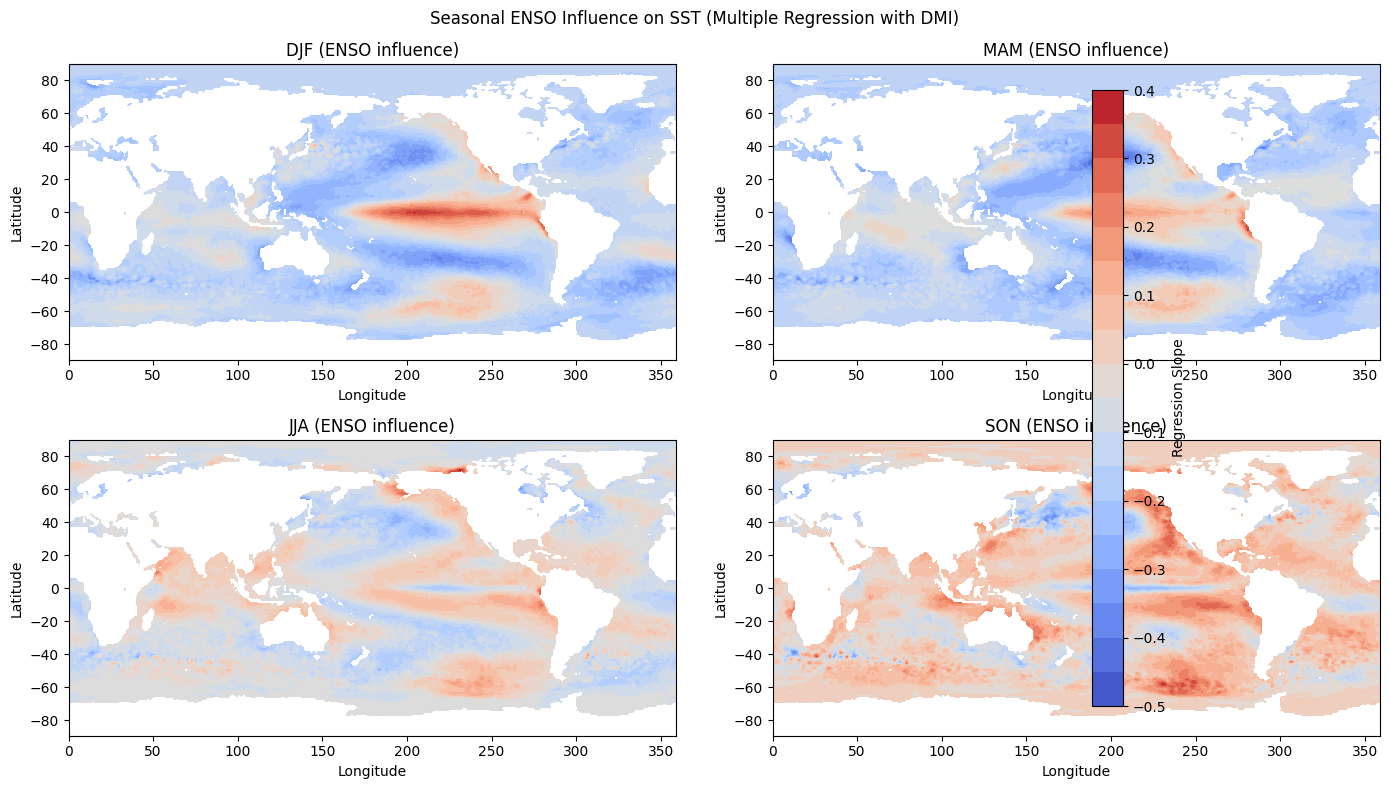

In [11]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------------------
# Load ENSO & DMI data
# -------------------------------
enso_file = "nino-3.4_7924_noaa.txt"
dmi_file  = "dmi_7924_noaa.txt"

enso_df = pd.read_csv(enso_file, delim_whitespace=True, header=None)
dmi_df  = pd.read_csv(dmi_file,  delim_whitespace=True, header=None)

enso_index = enso_df.iloc[:, 1].values
dmi_index  = dmi_df.iloc[:, 1].values

enso_monthly = np.repeat(enso_index, 12)
dmi_monthly  = np.repeat(dmi_index, 12)

# -------------------------------
# Load SST data
# -------------------------------
sst_file = "ERA5_SST_sst_K_monmean_7924_1.nc"
ds = xr.open_dataset(sst_file)

sst = ds["sst"]
time = ds["time"]
lat = ds["lat"]
lon = ds["lon"]

# Match lengths
enso_monthly = enso_monthly[:len(time)]
dmi_monthly  = dmi_monthly[:len(time)]

# Add to dataset
ds["enso"] = (("time"), enso_monthly)
ds["dmi"]  = (("time"), dmi_monthly)

# -------------------------------
# Define seasons
# -------------------------------
seasons = {
    "DJF":[12,1,2],
    "MAM":[3,4,5],
    "JJA":[6,7,8],
    "SON":[9,10,11]
}

# -------------------------------
# Plot setup
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# -------------------------------
# Loop over seasons
# -------------------------------
for idx, (season, months) in enumerate(seasons.items()):

    season_ds = ds.sel(time=ds["time"].dt.month.isin(months))

    enso_vals = season_ds["enso"].values
    dmi_vals  = season_ds["dmi"].values
    sst_vals  = season_ds["sst"].values

    # Prepare output maps
    slope_enso = np.zeros((len(lat), len(lon)))
    slope_dmi  = np.zeros((len(lat), len(lon)))

    # Grid-wise regression
    for i in range(len(lat)):
        for j in range(len(lon)):

            y = sst_vals[:, i, j]

            if np.isnan(y).any():
                slope_enso[i, j] = np.nan
                slope_dmi[i, j]  = np.nan
                continue

            X = np.column_stack((enso_vals, dmi_vals))

            model = LinearRegression()
            model.fit(X, y)

            slope_enso[i, j] = model.coef_[0]
            slope_dmi[i, j]  = model.coef_[1]

    # -------------------------------
    # Plot ENSO influence (you can switch to DMI if needed)
    # -------------------------------
    ax = axes[idx]

    c = ax.contourf(lon, lat, slope_enso, 20, cmap="coolwarm")

    ax.set_title(f"{season} (ENSO influence)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

# -------------------------------
# Colorbar
# -------------------------------
fig.colorbar(c, ax=axes, label="Regression Slope")

plt.suptitle("Seasonal ENSO Influence on SST (Multiple Regression with DMI)")

plt.tight_layout()
plt.show()